In [1]:
# Texts Processing

import spacy
nlp = spacy.load("en_core_web_lg")
from spacy.lang.en import stop_words
from spacy import displacy

from string import punctuation as PUNC
STOP_WORDS = stop_words.STOP_WORDS

# Data manipulation
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# Visualizations
import matplotlib.pyplot as plt

# Settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 50)

In [2]:
# First paragraph of desk description on WIKIPEDIA

text_to_analyse = "Desk-style furniture appears not to have been used in classical antiquity or in other ancient centers of literate civilization in the Middle East or Far East, but there is no specific proof. Medieval illustrations show the first pieces of furniture which seem to have been designed and constructed for reading and writing. Before the invention of the movable type printing press in the 15th century, any reader was potentially a writer or publisher or both, since any book or other document had to be copied by hand. The desks were designed with slots and hooks for bookmarks and for writing implements."

# ***Tokenization***

**Tokenization** is the process of splitting text into smaller units called **tokens**. In **spaCy**, tokenization is handled automatically when processing text and typically includes:
- **Words** (e.g., `dog`, `house`)
- **Punctuation** (e.g., `.`, `,`)
- **Symbols** (e.g., `€`, `@`)
- **Contractions and abbreviations** (e.g., `can't`, `U.S.`)

## Creating container - DOC

In [3]:
doc = nlp(text_to_analyse)

print(doc)

Desk-style furniture appears not to have been used in classical antiquity or in other ancient centers of literate civilization in the Middle East or Far East, but there is no specific proof. Medieval illustrations show the first pieces of furniture which seem to have been designed and constructed for reading and writing. Before the invention of the movable type printing press in the 15th century, any reader was potentially a writer or publisher or both, since any book or other document had to be copied by hand. The desks were designed with slots and hooks for bookmarks and for writing implements.


## ***Sentence Boundary Detection***

In [4]:
for index, sent in enumerate(doc.sents):
    print(index, sent)

0 Desk-style furniture appears not to have been used in classical antiquity or in other ancient centers of literate civilization in the Middle East or Far East, but there is no specific proof.
1 Medieval illustrations show the first pieces of furniture which seem to have been designed and constructed for reading and writing.
2 Before the invention of the movable type printing press in the 15th century, any reader was potentially a writer or publisher or both, since any book or other document had to be copied by hand.
3 The desks were designed with slots and hooks for bookmarks and for writing implements.


## ***Token attributes***

#### 🔤 Basic Token Information
- **Token** – original form of the word (e.g., `"Apple"`).
- **Lower** – lowercase form (e.g., `"apple"`).
- **Lemma** – base form of the word (e.g., `"be"` instead of `"was"`).
- **Norm** – normalized version (e.g., `"U.S.A."` → `"USA"`).

#### 🧠 Part-of-Speech and Morphosyntax
- **POS** – coarse-grained part-of-speech (e.g., `NOUN`, `VERB`).
- **Tag** – fine-grained POS tag (e.g., `VBZ`, `NNPS`).
- **Morph** – morphological features (e.g., tense, number, gender).
- **Dep** – syntactic dependency relation (e.g., `nsubj`, `obj`).
- **Conjuncts** – list of tokens in a conjunction (e.g., `"Tom and Jerry"` → `[Tom, Jerry]`).
- **LeftEdge** – the leftmost token of the syntactic subtree this token belongs to.
- **RightEdge** – the rightmost token of the syntactic subtree this token belongs to.

#### 🏷️ Annotations and Classification
- **IsStop** – whether the token is a stop word (`True`/`False`).
- **EntType** – named entity type (e.g., `PERSON`, `ORG`, `GPE`).
- **EntIOB** – position within named entity chunk (`B`, `I`, `O`).

#### 🧪 Textual Properties
- **IsAlpha** – whether the token consists of alphabetic characters.
- **IsDigit** – whether the token is a digit.
- **IsPunct** – whether the token is punctuation.
- **IsQuote** – whether the token is a quotation mark.
- **IsSpace** – whether the token is whitespace (space/tab).
- **IsBracket** – whether the token is a bracket.
- **IsCurrency** – whether the token is a currency symbol (`$`, `€`).

#### 🔍 Pattern Recognition
- **LikeNum** – whether the token looks like a number (`"five"`, `"123"`, `"1.2"`).
- **LikeURL** – whether the token looks like a URL.
- **LikeEMAIL** – whether the token looks like an email address.

#### 🧬 Semantic Vectors
- **HasVector** – whether the token has a word vector assigned.
- **VectorShape** – shape of the embedding vector (e.g., `(300,)` in `en_core_web_lg`).
- **VectorNorm** – L2 norm of the vector (used for similarity).
- **IsOOV** – whether the token is out-of-vocabulary (not in the model’s vocab).

#### 📊 Corpus Statistics (only in large models like `en_core_web_lg`)
- **Rank** – frequency rank of the token (lower = more frequent).
- **Prob** – log probability of the token’s occurrence (`log(prob)`).


In [5]:
def create_text_stats_df(text: str) -> pd.DataFrame:
    
    """Function that creates a dataframe with statistics for every word
    in a given text.
    Returns:
        pd.DataFrame: A dataframe with given text stats.
    """
    
    doc = nlp(text)

    data = []

    for token in doc:
        data.append({
            "Token": token.text,
            "Lower": token.lower_,
            "Lemma": token.lemma_,
            "Norm": token.norm_,
            "MostLeftEdge": token.left_edge,
            "MostRightEdge": token.right_edge,
            "Length": token.__len__(),
            "POS": token.pos_,
            "Tag": token.tag_,
            "Morph": token.morph.to_dict(),
            "Dep": token.dep_,
            "Conjuncts": token.conjuncts,
            "IsStop": token.is_stop,
            "IsAlpha": token.is_alpha,
            "IsDigit": token.is_digit,  
            "IsPunct": token.is_punct,  
            "IsQuote": token.is_quote,  
            "IsSpace": token.is_space,  
            "IsBracket": token.is_bracket,  
            "LikeNum": token.like_num,
            "LikeURL": token.like_url,
            "LikeEMAIL": token.like_email,
            "EntType": token.ent_type_,
            "EntIOB": token.ent_iob_,
            "IsCurrency": token.is_currency,      
            "HasVector": token.has_vector,
            "VectorShape": token.vector.shape,
            "VectorNorm": token.vector_norm,
            "IsOOV": token.is_oov,
            "Rank": token.rank,
            "Prob": token.prob
        })
        
    df = pd.DataFrame(data)

    return df

In [6]:
sentences = [sent.text for sent in doc.sents]

sent1 = sentences[0]
sent2 = sentences[1]
sent3 = sentences[2]
sent4 = sentences[3]

### ***Sentence 1***

In [7]:
print(sent1)

Desk-style furniture appears not to have been used in classical antiquity or in other ancient centers of literate civilization in the Middle East or Far East, but there is no specific proof.


In [8]:
create_text_stats_df(sent1)

,Token,Lower,Lemma,Norm,MostLeftEdge,MostRightEdge,Length,POS,Tag,Morph,Dep,Conjuncts,IsStop,IsAlpha,IsDigit,...,IsQuote,IsSpace,IsBracket,LikeNum,LikeURL,LikeEMAIL,EntType,EntIOB,IsCurrency,HasVector,VectorShape,VectorNorm,IsOOV,Rank,Prob
0,Desk,desk,desk,desk,Desk,Desk,4,NOUN,NN,{'Number': 'Sing'},compound,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.681356,False,51804,-20.0
1,-,-,-,-,-,-,1,PUNCT,HYPH,{'PunctType': 'Dash'},punct,(),False,False,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.603344,False,54691,-20.0
2,style,style,style,style,Desk,style,5,NOUN,NN,{'Number': 'Sing'},compound,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.194896,False,203406,-20.0
3,furniture,furniture,furniture,furniture,Desk,furniture,9,NOUN,NN,{'Number': 'Sing'},nsubj,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",7.521850,False,108386,-20.0
4,appears,appears,appear,appears,Desk,.,7,VERB,VBZ,"{'Number': 'Sing', 'Person': '3', 'Tense': 'Pr...",ROOT,"(is,)",False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.819267,False,129042,-20.0
5,not,not,not,not,not,not,3,PART,RB,{'Polarity': 'Neg'},neg,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.943608,False,91474,-20.0
6,to,to,to,to,to,to,2,PART,TO,{},aux,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.744840,False,210291,-20.0
7,have,have,have,have,have,have,4,AUX,VB,{'VerbForm': 'Inf'},aux,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.036123,False,116546,-20.0
8,been,been,be,been,been,been,4,AUX,VBN,"{'Tense': 'Past', 'VerbForm': 'Part'}",auxpass,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.245851,False,118220,-20.0
9,used,used,use,used,not,East,4,VERB,VBN,"{'Aspect': 'Perf', 'Tense': 'Past', 'VerbForm'...",xcomp,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.209864,False,47137,-20.0


In [9]:
doc1 = nlp(sent1)

print(doc1.ents)

(the Middle East, Far East)


### ***Sentence 2***

In [10]:
print(sent2)

Medieval illustrations show the first pieces of furniture which seem to have been designed and constructed for reading and writing.


In [11]:
create_text_stats_df(sent2)

,Token,Lower,Lemma,Norm,MostLeftEdge,MostRightEdge,Length,POS,Tag,Morph,Dep,Conjuncts,IsStop,IsAlpha,IsDigit,...,IsQuote,IsSpace,IsBracket,LikeNum,LikeURL,LikeEMAIL,EntType,EntIOB,IsCurrency,HasVector,VectorShape,VectorNorm,IsOOV,Rank,Prob
0,Medieval,medieval,medieval,medieval,Medieval,Medieval,8,ADJ,JJ,{'Degree': 'Pos'},amod,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",7.266811,False,163670,-20.0
1,illustrations,illustrations,illustration,illustrations,Medieval,illustrations,13,NOUN,NNS,{'Number': 'Plur'},nsubj,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",7.050664,False,29399,-20.0
2,show,show,show,show,Medieval,.,4,VERB,VBP,"{'Tense': 'Pres', 'VerbForm': 'Fin'}",ROOT,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.705889,False,33582,-20.0
3,the,the,the,the,the,the,3,DET,DT,"{'Definite': 'Def', 'PronType': 'Art'}",det,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.709350,False,194743,-20.0
4,first,first,first,first,first,first,5,ADJ,JJ,{'Degree': 'Pos'},amod,(),True,True,False,...,False,False,False,True,False,False,ORDINAL,B,False,True,"(300,)",5.042608,False,203956,-20.0
5,pieces,pieces,piece,pieces,the,writing,6,NOUN,NNS,{'Number': 'Plur'},dobj,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.206809,False,178357,-20.0
6,of,of,of,of,of,furniture,2,ADP,IN,{},prep,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.977930,False,124210,-20.0
7,furniture,furniture,furniture,furniture,furniture,furniture,9,NOUN,NN,{'Number': 'Sing'},pobj,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",7.521850,False,108386,-20.0
8,which,which,which,which,which,which,5,PRON,WDT,{},nsubj,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.960123,False,180487,-20.0
9,seem,seem,seem,seem,which,writing,4,VERB,VBP,"{'Tense': 'Pres', 'VerbForm': 'Fin'}",relcl,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.436571,False,62968,-20.0


In [12]:
doc2 = nlp(sent2)

print(doc2.ents)

(first,)


### ***Sentence 3***

In [13]:
print(sent3)

Before the invention of the movable type printing press in the 15th century, any reader was potentially a writer or publisher or both, since any book or other document had to be copied by hand.


In [14]:
create_text_stats_df(sent3)

,Token,Lower,Lemma,Norm,MostLeftEdge,MostRightEdge,Length,POS,Tag,Morph,Dep,Conjuncts,IsStop,IsAlpha,IsDigit,...,IsQuote,IsSpace,IsBracket,LikeNum,LikeURL,LikeEMAIL,EntType,EntIOB,IsCurrency,HasVector,VectorShape,VectorNorm,IsOOV,Rank,Prob
0,Before,before,before,before,Before,century,6,ADP,IN,{},prep,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.212118,False,240855,-20.0
1,the,the,the,the,the,the,3,DET,DT,"{'Definite': 'Def', 'PronType': 'Art'}",det,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.709350,False,194743,-20.0
2,invention,invention,invention,invention,the,century,9,NOUN,NN,{'Number': 'Sing'},pobj,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",7.206082,False,83442,-20.0
3,of,of,of,of,of,press,2,ADP,IN,{},prep,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.977930,False,124210,-20.0
4,the,the,the,the,the,the,3,DET,DT,"{'Definite': 'Def', 'PronType': 'Art'}",det,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.709350,False,194743,-20.0
5,movable,movable,movable,movable,movable,movable,7,ADJ,JJ,{'Degree': 'Pos'},amod,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",7.104406,False,255327,-20.0
6,type,type,type,type,movable,type,4,NOUN,NN,{'Number': 'Sing'},compound,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.989347,False,158249,-20.0
7,printing,printing,print,printing,printing,printing,8,VERB,VBG,"{'Aspect': 'Prog', 'Tense': 'Pres', 'VerbForm'...",compound,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",7.288692,False,18436,-20.0
8,press,press,press,press,the,press,5,NOUN,NN,{'Number': 'Sing'},pobj,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.011513,False,26939,-20.0
9,in,in,in,in,in,century,2,ADP,IN,{},prep,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",5.092986,False,133524,-20.0


In [15]:
doc3 = nlp(sent3)

print(doc3.ents)

(the 15th century,)


### ***Sentence 4***

In [16]:
print(sent4)

The desks were designed with slots and hooks for bookmarks and for writing implements.


In [17]:
create_text_stats_df(sent4)

,Token,Lower,Lemma,Norm,MostLeftEdge,MostRightEdge,Length,POS,Tag,Morph,Dep,Conjuncts,IsStop,IsAlpha,IsDigit,...,IsQuote,IsSpace,IsBracket,LikeNum,LikeURL,LikeEMAIL,EntType,EntIOB,IsCurrency,HasVector,VectorShape,VectorNorm,IsOOV,Rank,Prob
0,The,the,the,the,The,The,3,DET,DT,"{'Definite': 'Def', 'PronType': 'Art'}",det,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.709350,False,194743,-20.0
1,desks,desks,desk,desks,The,desks,5,NOUN,NNS,{'Number': 'Plur'},nsubjpass,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.969784,False,44238,-20.0
2,were,were,be,were,were,were,4,AUX,VBD,"{'Mood': 'Ind', 'Tense': 'Past', 'VerbForm': '...",auxpass,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.003382,False,54792,-20.0
3,designed,designed,design,designed,The,.,8,VERB,VBN,"{'Aspect': 'Perf', 'Tense': 'Past', 'VerbForm'...",ROOT,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.016016,False,138707,-20.0
4,with,with,with,with,with,implements,4,ADP,IN,{},prep,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.770858,False,78523,-20.0
5,slots,slots,slot,slots,slots,implements,5,NOUN,NNS,{'Number': 'Plur'},pobj,"(hooks,)",False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",7.074305,False,298921,-20.0
6,and,and,and,and,and,and,3,CCONJ,CC,{'ConjType': 'Cmp'},cc,(),True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.657798,False,59023,-20.0
7,hooks,hooks,hook,hooks,hooks,hooks,5,NOUN,NNS,{'Number': 'Plur'},conj,"(slots,)",False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.506395,False,137157,-20.0
8,for,for,for,for,for,implements,3,ADP,IN,{},prep,"(for,)",True,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",4.843508,False,61856,-20.0
9,bookmarks,bookmarks,bookmark,bookmarks,bookmarks,bookmarks,9,NOUN,NNS,{'Number': 'Plur'},pobj,(),False,True,False,...,False,False,False,False,False,False,,O,False,True,"(300,)",6.506779,False,35455,-20.0


In [18]:
doc4 = nlp(sent4)

print(doc4.ents)

()


In [19]:
displacy.render(doc4, style = "dep")

### ***Whole text***

In [20]:
displacy.render(doc, style = "ent")

# ***Word Vectors***

## ***DOC Similarity***

#### ***Word Similarity***

In [21]:
word1 = nlp("Apple")
word2 = nlp("Orange")
word3 = nlp("Football")

word4 = nlp("Pitch")

print(f'Similarity of word: {word4} to:')
for old_doc in [word1, word2, word3]:
    print(old_doc, "=>", old_doc.similarity(word4))

Similarity of word: Pitch to:
Apple => 0.09662427753210068
Orange => 0.14704006910324097
Football => 0.2937447726726532


In [22]:
def find_most_similar_word(word, n = 10):
    
    doc = nlp(word)
    
    vector =  np.asarray([doc.vector])
    words, best_rows, scores = nlp.vocab.vectors.most_similar(vector, n = n)
    
    words = [nlp.vocab.strings[word] for word in words[0]]
    
    results = pd.DataFrame(
        data = zip(words, scores[0]),
        columns = ['Word', 'Similarity']
    )
    
    return results

In [24]:
%%time

find_most_similar_word("football")

CPU times: total: 453 ms
Wall time: 478 ms


,Word,Similarity
0,FootBall,1.0000
1,SOCCER,0.8353
2,BASKETBALL,0.7925
3,BASEBALL,0.7168
4,RUGBY,0.7145
5,LEague,0.6978
6,SPORTS,0.6939
7,HOCKEY,0.6687
8,ATHLETICS,0.6654
9,COACH,0.6560


In [47]:
%%time

find_most_similar_word("gaming pad", 5)

CPU times: total: 469 ms
Wall time: 477 ms


,Word,Similarity
0,GAMING,0.8063
1,PaD,0.7475
2,GAMERS,0.5906
3,PADs,0.5773
4,GAMER,0.5763


In [48]:
%%time

find_most_similar_word("talk", 15)

CPU times: total: 672 ms
Wall time: 484 ms


,Word,Similarity
0,TaLK,1.0000
1,TALKING,0.8034
2,TALKED,0.7204
3,SPEAK,0.7102
4,CONVERSATION,0.6921
5,TELL,0.6867
6,TELLING,0.6725
7,DISCUSS,0.6686
8,TALKS,0.6615
9,knOw,0.6580


#### ***Sentence Similarity***

In [27]:
new_sent1 = "I like playing football."
new_sent2 = "I like sitting on my desk."

doc5 = nlp(new_sent1)
doc6 = nlp(new_sent2)

print(f'Similarity of sentence: "{new_sent1}" with:')
for index, old_doc in enumerate([doc1, doc2, doc3, doc4]):
    print(index, old_doc.similarity(doc5))
    
print()
    
print(f'Similarity of sentence: "{new_sent2}" with:')
for index, old_doc in enumerate([doc1, doc2, doc3, doc4]):
    print(index, old_doc.similarity(doc6))

Similarity of sentence: "I like playing football." with:
0 0.6885818839073181
1 0.6664562225341797
2 0.6556342840194702
3 0.6039106249809265

Similarity of sentence: "I like sitting on my desk." with:
0 0.757423460483551
1 0.7473378777503967
2 0.7461955547332764
3 0.7340966463088989


## ***Visualizations***

In default spaCy object have size of (300, ) so to visualize we have to use some methods od dimenstionality reduction.

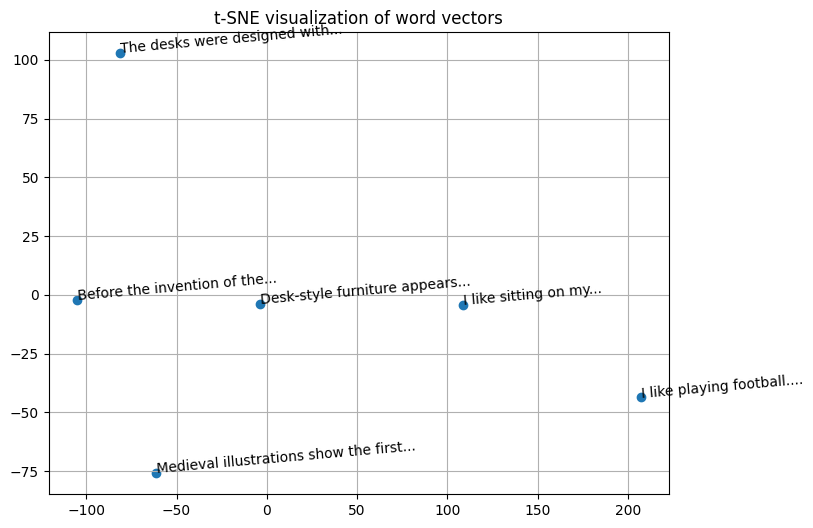

In [36]:
vectors = [nlp(sentence).vector for sentence in sentences] + [doc5.vector] + [doc6.vector]
vectors = np.array(vectors)

# Dimensionality reduction
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 3)
vectors_2d = tsne.fit_transform(vectors)

# Visualizations
plt.figure(figsize=(8,6))
plt.scatter(vectors_2d[:,0], vectors_2d[:,1])

for i, sent in enumerate(sentences + [new_sent1, new_sent2]):
    doc = nlp(sent)
    plt.annotate(f'{doc[:5]}...', xy = (vectors_2d[i, 0], vectors_2d[i, 1]), rotation = 5)

plt.title("t-SNE visualization of word vectors")
plt.grid()
plt.show()

# ***Word Vectors***

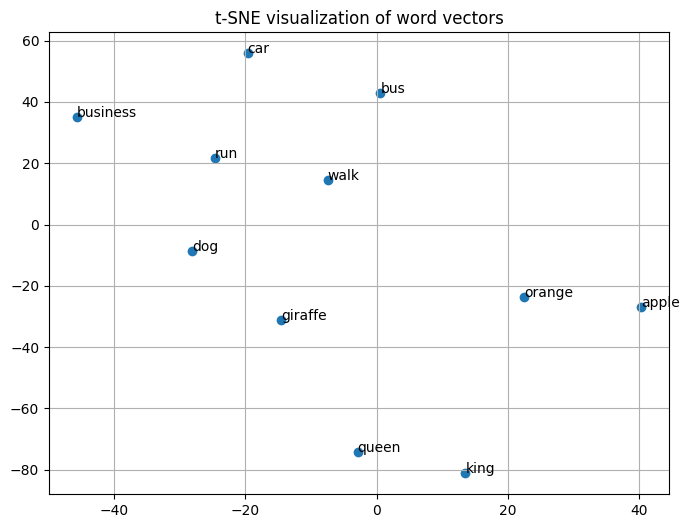

In [37]:
# Words to visualizations
words = ["dog", "giraffe", "apple", "orange", "car", "bus", "run", "walk", "king", "queen", "business"]
vectors = np.array([nlp.vocab[word].vector for word in words])

# Dimensionality reduction
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 5)
vectors_2d = tsne.fit_transform(vectors)

# Visualizations
plt.figure(figsize=(8,6))
plt.scatter(vectors_2d[:,0], vectors_2d[:,1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i,0], vectors_2d[i,1]))

plt.title("t-SNE visualization of word vectors")
plt.grid()
plt.show()

In [38]:
def find_top_similar(target_word, candidates, top_n = 5):
    target_vector = nlp.vocab[target_word].vector.reshape(1, -1)
    results = []

    for word in candidates:
        candidate_vector = nlp.vocab[word].vector.reshape(1, -1)
        similarity = cosine_similarity(target_vector, candidate_vector)[0][0]
        results.append({"Word": word, "Similarity": similarity})

    df = pd.DataFrame(results)
    df = df.sort_values(by="Similarity", ascending=False).reset_index(drop=True)
    return df.head(top_n)

In [44]:
target = "football"

find_top_similar(target, words, top_n = 5)

,Word,Similarity
0,run,0.294186
1,dog,0.261028
2,business,0.237552
3,car,0.230324
4,orange,0.216523


In [45]:
target = "football"

find_top_similar(target, ['soccer', 'volleyball', 'basketball', 'player'], top_n = 5)

,Word,Similarity
0,soccer,0.835294
1,basketball,0.792509
2,volleyball,0.637085
3,player,0.553176


# ***Pipelines***

![spaCy pipeline](../images/spacy_pipeline.png)

In [55]:
# Classical model pipeline
nlp.analyze_pipes()['summary'].keys()

dict_keys(['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner'])

In [63]:
# In both cases Tesla will be classified as ORGANIZATION

t1 = "Tesla was a great scientist."
t2 = "Tesla is a big company."

doc = nlp(t1)

for ent in doc.ents:
    print(ent, ent.label_)
    
doc = nlp(t2)

for ent in doc.ents:
    print(ent, ent.label_)

Tesla ORG
Tesla ORG


## ***Entity Ruler***

In [67]:
# In both cases now Tesla will be classified as PERSON

nlp2 = spacy.load("en_core_web_lg")
ruler = nlp2.add_pipe("entity_ruler", before = "ner")
patterns = [
    {"label": "PERSON", "pattern": "Tesla"}
]
ruler.add_patterns(patterns)

doc = nlp2(t1)

for ent in doc.ents:
    print(ent, ent.label_)
    
doc = nlp2(t2)

for ent in doc.ents:
    print(ent, ent.label_)
    
nlp2.analyze_pipes()['summary'].keys()

Tesla PERSON
Tesla PERSON


dict_keys(['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner'])

In [71]:
# Trying to catch up with ETF ISIN

t3 = "US4642882579 is much better than IE00B5BMR087 for beginners."

doc = nlp(t3)

for ent in doc.ents:
    print(ent, ent.label_)

IE00B5BMR087 GPE


In [72]:
nlp3 = spacy.load("en_core_web_lg")
ruler = nlp3.add_pipe("entity_ruler", before = "ner")   
patterns = [
    {
        "label": "ETF",
        "pattern": [{"TEXT": {"REGEX": r"^[A-Z]{2}[A-Z0-9]{10}$"}}]
    }
]
ruler.add_patterns(patterns)

doc = nlp3(t3)

for ent in doc.ents:
    print(ent, ent.label_)

US4642882579 ETF
IE00B5BMR087 ETF


## ***Matcher***

In [77]:
from spacy.matcher import Matcher
from spacy.tokens import Span

t4 = "Huge thanks to @elonmusk, @nasa and @SpaceX for making last night's launch unforgettable! 🚀 Also, great coverage by @techreview and @spacenerds."

In [78]:
# Classic 

doc = nlp(t4)

for ent in doc.ents:
    print(ent, ent.label_)

last night's TIME


In [84]:
# Catch up with all mentions of other users

nlp4 = spacy.load("en_core_web_lg")
matcher = Matcher(nlp4.vocab)

pattern = [
    {
        "TEXT": {"REGEX": r"^@\w+"}
    }
]

matcher.add("MENTION", [pattern])

doc = nlp4(t4)
matches = matcher(doc)

for match_id, start, end in matches:
    span = Span(doc, start, end, label = "MENTION")
    doc.ents += (span,)
    
for ent in doc.ents:
    print(ent.text, ent.label_)

@elonmusk MENTION
@nasa MENTION
@SpaceX MENTION
last night's TIME
@techreview MENTION
@spacenerds MENTION


In [ ]:
# Creating a matcher to extract 

sentences = [
    "She has finished her homework.",
    "I have seen that movie already.",
    "They have visited Paris twice.",
    "They have never visited Rome.",
    "I have not visited London yet.",
    "We have already seen that movie.",
    "She has finished her homework.",
    "I've never seen this before.",
    "She hasn't finished yet.",
    "You haven't ever tried this."
]

nlp5 = spacy.load("en_core_web_lg")
matcher = Matcher(nlp5.vocab)

present_perfect_patterns = [
    [{"LOWER": {"IN": ["have", "has"]}},
     {"POS": "ADV", "OP": "*"},
     {"POS": "VERB", "TAG": "VBN"}],
    
    [{"LOWER": {"IN": ["'ve", "'s"]}},
     {"POS": "ADV", "OP": "*"},
     {"POS": "VERB", "TAG": "VBN"}],

    [{"LOWER": {"IN": ["have", "has"]}},
     {"LOWER": "not"},
     {"POS": "ADV", "OP": "*"},
     {"POS": "VERB", "TAG": "VBN"}],

    [{"LOWER": {"IN": ["have", "has"]}},
     {"LOWER": "n't"},
     {"POS": "ADV", "OP": "*"},
     {"POS": "VERB", "TAG": "VBN"}]
]

matcher.add("PRESENT_PERFECT", present_perfect_patterns)

print(f"Sentences list length: {len(sentences)}.\n")

max_length_sentence = max([len(sentence) for sentence in sentences])

for idx, sentence in enumerate(sentences):
    
    
    
    spaces_length = max_length_sentence - len(sentence) 
    
    doc = nlp5(sentence)
    matches = matcher(doc)
    
    for match_id, start, end in matches:
        span = doc[start:end]
        print(f"Sentence {str(idx + 1).zfill(2)}: {sentence}{' ' * (spaces_length + 1)}➡️ {span.text}")
    

Sentences list length: 10.

Sentence 01: She has finished her homework.   ➡️ has finished
Sentence 02: I have seen that movie already.  ➡️ have seen
Sentence 03: They have visited Paris twice.   ➡️ have visited
Sentence 04: They have never visited Rome.    ➡️ have never visited
Sentence 05: I have not visited London yet.   ➡️ have not visited
Sentence 06: We have already seen that movie. ➡️ have already seen
Sentence 07: She has finished her homework.   ➡️ has finished
Sentence 08: I've never seen this before.     ➡️ 've never seen
Sentence 09: She hasn't finished yet.         ➡️ hasn't finished
Sentence 10: You haven't ever tried this.     ➡️ haven't ever tried
